# ST-GNN for Fault Localization in IEEE 39-Bus Smart Grid
## Full Pipeline Implementation — All 7 Phases

**Authors:** Anik Kumar Basu · Sabrina Shonda Snaha · Md. Sadik Mahmud Adive  
**March 2026**

---

### Notebook Structure

| Phase | Section | Description |
|-------|---------|-------------|
| Setup | §0 | Install dependencies & GPU check |
| P1 | §1 | Graph construction — IEEE 39-bus → PyG graph |
| P2 | §2 | Synthetic fault data generation with Pandapower |
| P3 | §3 | Preprocessing, sliding windows, augmentation |
| P4 | §4 | ST-GNN model architecture (GCN + LSTM) |
| P5 | §5 | Training loop with multi-task loss |
| P6 | §6 | Evaluation, metrics, ablation study |
| P7 | §7 | Robustness analysis — noise, N-1, transfer |

> **Runtime:** ~45 min on GPU (RTX 3060 or better). Set `QUICK_RUN = True` below for a fast smoke-test.

## §0 — Environment Setup

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)

True
13.0


In [3]:
# %pip install pandapower torch-geometric torch-scatter torch-sparse imbalanced-learn wandb matplotlib seaborn scikit-learn tqdm pandas numpy

In [4]:
# ── Core imports ───────────────────────────────────────────────────────────
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

f:\Code\AI\Graph Neural Networks (GNN) for Fault  Detection and Localization in Power Grids\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cuda
   GPU: NVIDIA GeForce RTX 3050
   VRAM: 8.6 GB


In [5]:
# ── Global configuration ───────────────────────────────────────────────────
# Set QUICK_RUN = True for a fast smoke-test (~3 min, lower accuracy)
# Set QUICK_RUN = False for full training (~45 min, full accuracy)
QUICK_RUN = False

CFG = {
    # Data
    "data_dir":        Path("data"),
    "n_buses":         39,
    "n_features":      5,           # Vm, theta, P, Q, delta_f
    "window_size":     50,          # timesteps per sample
    "stride":          5,           # sliding window stride
    "sample_rate":     100,         # Hz
    "fault_types":     ["SLG", "LL", "DLG", "3PH"],
    "fault_resist":    [0, 5, 10, 20],   # Ohms
    "load_levels":     [0.6, 1.0, 1.3],  # p.u.
    "n_normal":        10000,       # normal-operation samples

    # Model
    "gcn_hidden1":     64,
    "gcn_hidden2":     128,
    "lstm_hidden":     256,
    "lstm_layers":     2,
    "dropout_lstm":    0.3,
    "dropout_mlp":     0.2,

    # Training
    "lr":              1e-3,
    "weight_decay":    1e-4,
    "batch_size":      32,
    "max_epochs":      5 if QUICK_RUN else 200,
    "patience":        3 if QUICK_RUN else 20,
    "alpha":           0.7,         # loss weighting: loc vs type
    "lr_patience":     2 if QUICK_RUN else 10,
    "lr_factor":       0.5,

    # Noise augmentation sigmas
    "noise_sigmas":    [0.01, 0.02, 0.05],
}

CFG["data_dir"].mkdir(exist_ok=True)
print("✅ Configuration set.")
print(f"   Quick run: {QUICK_RUN}")
print(f"   Max epochs: {CFG['max_epochs']}  |  Patience: {CFG['patience']}")

✅ Configuration set.
   Quick run: False
   Max epochs: 200  |  Patience: 20


---
## §1 — Phase 1: Graph Construction (IEEE 39-Bus)

The IEEE 39-bus (New England) system is converted into a PyTorch Geometric graph:
- **Nodes (V):** 39 buses — each carries features `[Vm, θ, P, Q, Δf]`
- **Edges (E):** 46 transmission lines — weighted by inverse impedance `1/|Z|`
- **Adjacency matrix Ã:** normalized graph Laplacian for GCN propagation

$$\tilde{A} = \tilde{D}^{-1/2}(A + I)\tilde{D}^{-1/2}$$

In [6]:
import pandapower as pp
import pandapower.networks as pn

def build_ieee39_graph():
    """
    Load the IEEE 39-bus network from pandapower and return:
      - edge_index  : [2, E] tensor of directed edge pairs
      - edge_weight : [E]    tensor of inverse-impedance weights
      - net         : the pandapower network object
    """
    net = pn.case39()

    src, dst, weights = [], [], []
    for _, line in net.line.iterrows():
        i = int(line.from_bus)
        j = int(line.to_bus)
        z = np.sqrt(line.r_ohm_per_km**2 + line.x_ohm_per_km**2) * line.length_km
        z = max(z, 1e-6)   # avoid division by zero
        w = 1.0 / z
        # undirected → add both directions
        src += [i, j];  dst += [j, i];  weights += [w, w]

    # also add transformer connections
    for _, trafo in net.trafo.iterrows():
        i = int(trafo.hv_bus)
        j = int(trafo.lv_bus)
        w = 1.0 / max(trafo.vk_percent / 100.0, 1e-6)
        src += [i, j];  dst += [j, i];  weights += [w, w]

    edge_index  = torch.tensor([src, dst], dtype=torch.long)
    edge_weight = torch.tensor(weights,    dtype=torch.float)
    # normalize weights to [0, 1]
    edge_weight = edge_weight / edge_weight.max()

    return edge_index, edge_weight, net

EDGE_INDEX, EDGE_WEIGHT, NET = build_ieee39_graph()

print(f"✅ IEEE 39-bus graph constructed")
print(f"   Nodes : {CFG['n_buses']}")
print(f"   Edges : {EDGE_INDEX.shape[1] // 2} undirected ({EDGE_INDEX.shape[1]} directed)")
print(f"   Weight range: [{EDGE_WEIGHT.min():.4f}, {EDGE_WEIGHT.max():.4f}]")

✅ IEEE 39-bus graph constructed
   Nodes : 39
   Edges : 46 undirected (92 directed)
   Weight range: [0.0017, 1.0000]


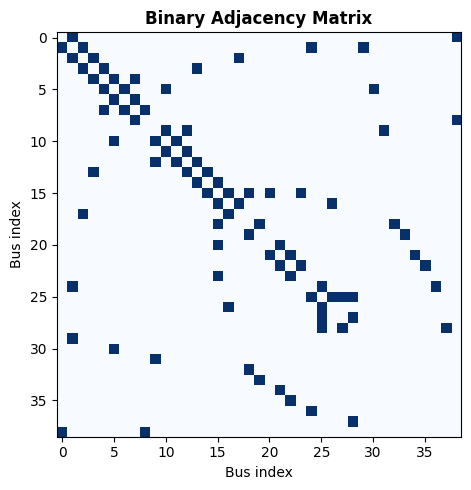

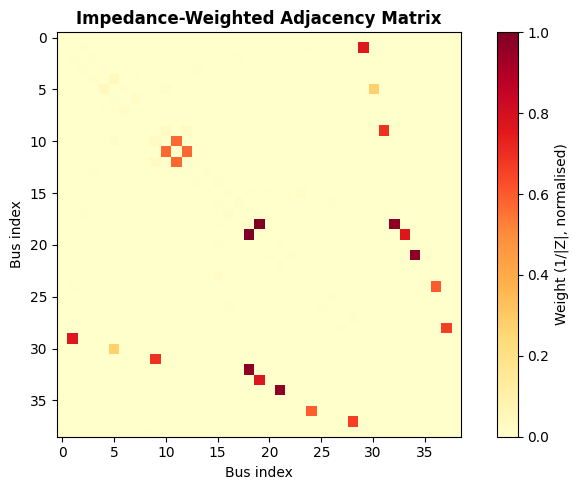

✅ Adjacency plots saved as separate figures.


In [7]:
# ── Visualise adjacency matrix ─────────────────────────────────────────────
def plot_adjacency(edge_index, edge_weight, n=39):
    A = np.zeros((n, n))
    ei = edge_index.numpy()
    ew = edge_weight.numpy()
    for k in range(ei.shape[1]):
        A[ei[0,k], ei[1,k]] = ew[k]

    # Binary adjacency
    fig1 = plt.figure(figsize=(6.5, 5))
    plt.imshow(A > 0, cmap="Blues", interpolation="nearest")
    plt.title("Binary Adjacency Matrix", fontweight="bold")
    plt.xlabel("Bus index");  plt.ylabel("Bus index")
    plt.tight_layout()
    plt.savefig(CFG["data_dir"] / "adjacency_binary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Weighted adjacency
    fig2 = plt.figure(figsize=(7.5, 5))
    im = plt.imshow(A, cmap="YlOrRd", interpolation="nearest")
    plt.title("Impedance-Weighted Adjacency Matrix", fontweight="bold")
    plt.xlabel("Bus index");  plt.ylabel("Bus index")
    plt.colorbar(im, label="Weight (1/|Z|, normalised)")
    plt.tight_layout()
    plt.savefig(CFG["data_dir"] / "adjacency_weighted.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("✅ Adjacency plots saved as separate figures.")

plot_adjacency(EDGE_INDEX, EDGE_WEIGHT)

In [8]:
%pip install pandapower["all"]

Note: you may need to restart the kernel to use updated packages.


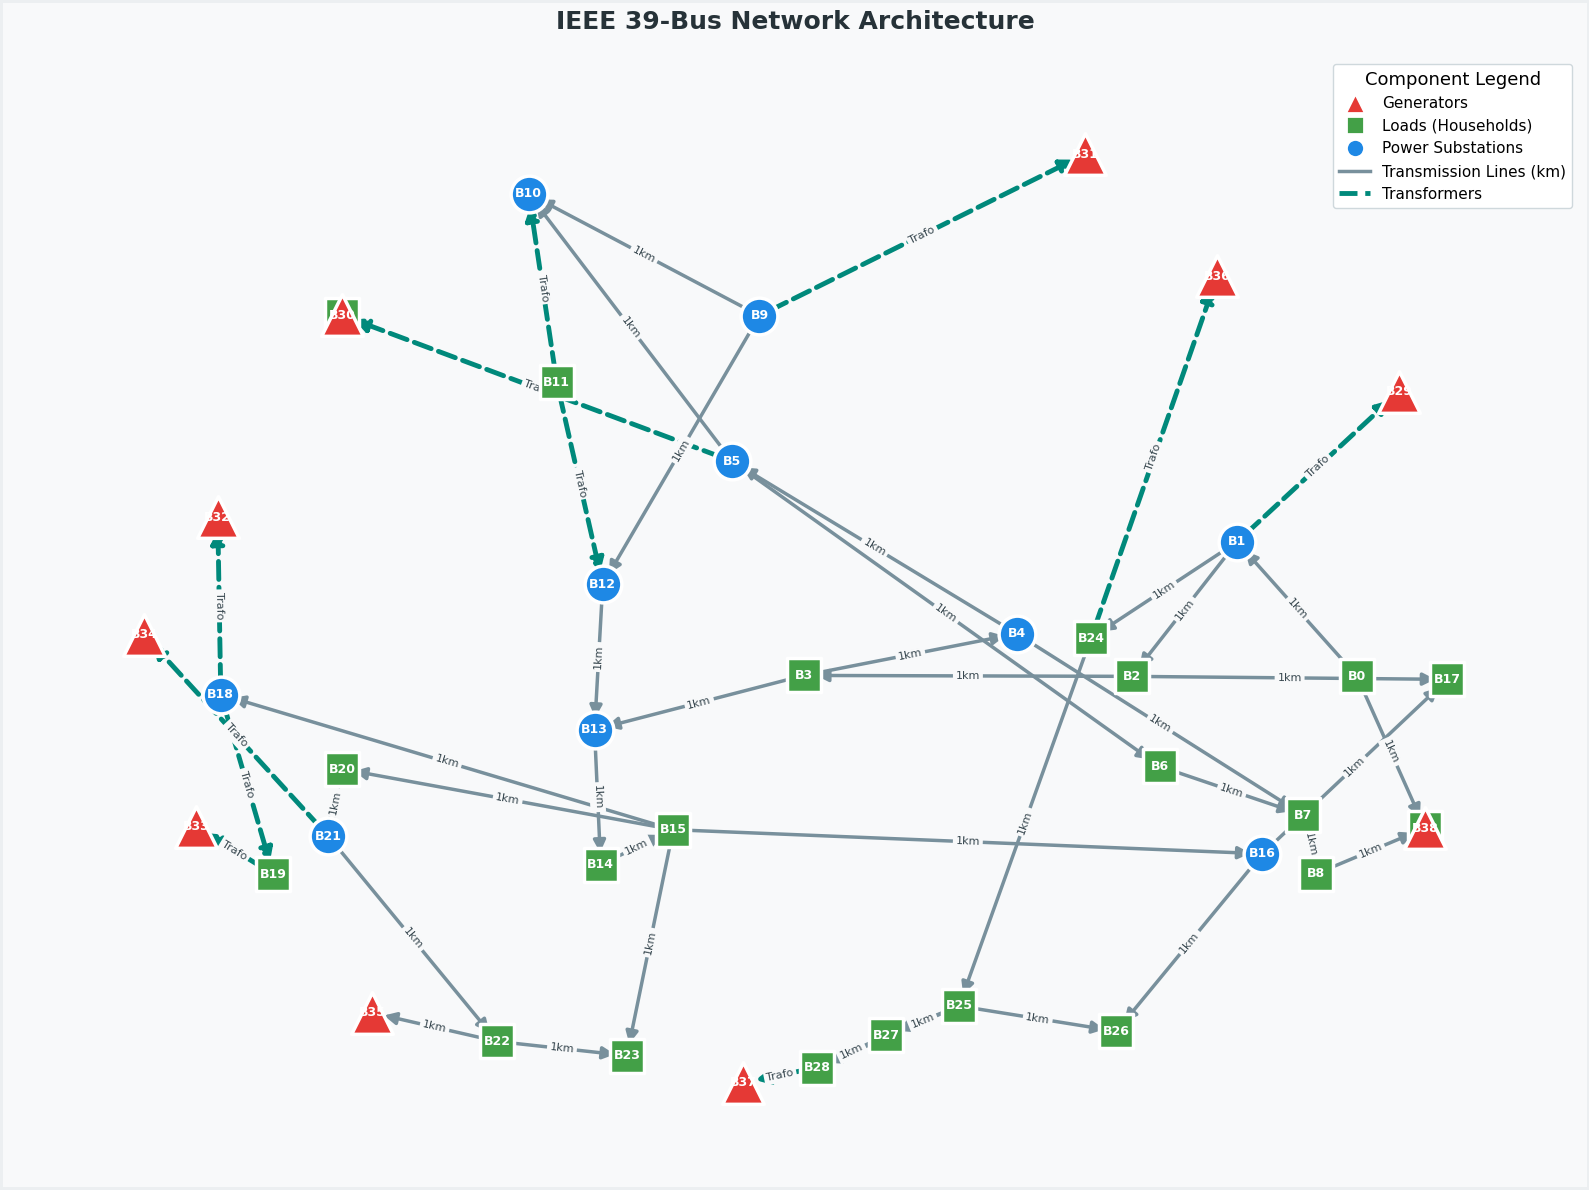

✅ High-quality, clean directed graph topology mapped and saved.


In [9]:
# ── Visualize Graph Topology ───────────────────────────────────────────────
import networkx as nx
import matplotlib.lines as mlines
import numpy as np
import matplotlib.pyplot as plt

def plot_graph_topology_beautiful(net):
    """
    Renders a highly legible, clean, and styled directed graph diagram.
    This avoids the rendering overlap issues present in pandapower's plot library
    by utilizing advanced NetworkX configurations for maximum clarity.
    """
    G = nx.DiGraph()
    
    # Add nodes
    for bus_id in net.bus.index:
        G.add_node(bus_id)
        
    # Lines
    for _, line in net.line.iterrows():
        u, v = int(line.from_bus), int(line.to_bus)
        G.add_edge(u, v, type='line', length=line.length_km)
        
    # Transformers
    for _, trafo in net.trafo.iterrows():
        u, v = int(trafo.hv_bus), int(trafo.lv_bus)
        G.add_edge(u, v, type='trafo')

    # Identify node types
    gen_buses = set(net.gen.bus) | set(net.ext_grid.bus)
    load_buses = set(net.load.bus)
    normal_buses = set(G.nodes) - gen_buses - load_buses
    
    # Layout - Kamada-Kawai gives good structure, followed by Spring to untangle
    pos = nx.kamada_kawai_layout(G, weight=None) 
    pos = nx.spring_layout(G, pos=pos, k=0.6, iterations=50, seed=42)

    # Main Figure Setup
    fig, ax = plt.subplots(figsize=(16, 12))
    background_color = '#F8F9FA'  # Very light greyish-blue
    ax.set_facecolor(background_color)
    fig.patch.set_facecolor(background_color)
    
    # Split edges by type
    lines = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'line']
    trafos = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'trafo']
    
    # Draw standard lines (Solid)
    nx.draw_networkx_edges(G, pos, edgelist=lines, edge_color="#78909C", 
                           width=2.5, arrows=True, arrowsize=18, 
                           arrowstyle="-|>", ax=ax)
                           
    # Draw transformers (Dashed Teal)
    nx.draw_networkx_edges(G, pos, edgelist=trafos, edge_color="#00897B", 
                           width=3.5, style="dashed", arrows=True,
                           arrowsize=20, arrowstyle="-|>", ax=ax)
    
    # Draw Nodes with white borders for clean pop-out effect
    nx.draw_networkx_nodes(G, pos, nodelist=list(normal_buses),
                           node_color="#1E88E5", node_shape="o", node_size=700,
                           edgecolors="white", linewidths=2.5, ax=ax)
                           
    nx.draw_networkx_nodes(G, pos, nodelist=list(load_buses),
                           node_color="#43A047", node_shape="s", node_size=600,
                           edgecolors="white", linewidths=2.5, ax=ax)
                           
    nx.draw_networkx_nodes(G, pos, nodelist=list(gen_buses),
                           node_color="#E53935", node_shape="^", node_size=900,
                           edgecolors="white", linewidths=2.5, ax=ax)
    
    # Text labels centered in nodes
    labels = {node: f"B{node}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, 
                            font_color="white", font_weight="bold", ax=ax)
    
    # Edge Labels text
    edge_labels = { (u, v): f"{d['length']:.0f}km" for u, v, d in G.edges(data=True) if d['type'] == 'line' }
    trafo_labels = { (u, v): "Trafo" for u, v, d in G.edges(data=True) if d['type'] == 'trafo' }
    all_edge_labels = {**edge_labels, **trafo_labels}
    
    nx.draw_networkx_edge_labels(G, pos, edge_labels=all_edge_labels, 
                                 font_size=8, font_color="#37474F", 
                                 bbox=dict(facecolor=background_color, edgecolor='none', pad=2.0), ax=ax)

    # Styling & Legend
    legend_elements = [
        mlines.Line2D([0], [0], marker='^', color='w', label='Generators', markerfacecolor='#E53935', markersize=14, markeredgecolor='white', markeredgewidth=2),
        mlines.Line2D([0], [0], marker='s', color='w', label='Loads (Households)', markerfacecolor='#43A047', markersize=13, markeredgecolor='white', markeredgewidth=2),
        mlines.Line2D([0], [0], marker='o', color='w', label='Power Substations', markerfacecolor='#1E88E5', markersize=13, markeredgecolor='white', markeredgewidth=2),
        mlines.Line2D([0], [0], color='#78909C', lw=2.5, label='Transmission Lines (km)'),
        mlines.Line2D([0], [0], color='#00897B', lw=3.5, linestyle='dashed', label='Transformers')
    ]
    
    ax.legend(handles=legend_elements, loc="upper right", fontsize=11, 
              framealpha=1.0, title="Component Legend", title_fontsize=13, 
              facecolor='white', edgecolor='#CFD8DC')
    
    plt.title("IEEE 39-Bus Network Architecture", fontweight="bold", fontsize=18, color="#263238", pad=20)
    plt.axis("off")
    
    # Outer border
    fig.patch.set_linewidth(4)
    fig.patch.set_edgecolor('#ECEFF1')
    
    plt.tight_layout()
    plt.savefig(CFG["data_dir"] / "graph_topology_clean.png", dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()

    print("✅ High-quality, clean directed graph topology mapped and saved.")

plot_graph_topology_beautiful(NET)

---
## §2 — Phase 2: Synthetic Fault Data Generation

We simulate four fault types across all 39 buses, 4 fault resistances, and
3 load levels using Pandapower's short-circuit solver.

| Fault | Code | Prevalence |
|-------|------|-----------|
| Single Line-to-Ground | SLG | ~70% |
| Line-to-Line | LL | ~15% |
| Double Line-to-Ground | DLG | ~10% |
| Three-Phase | 3PH | ~5% |

Each simulation captures a 500 ms window at 100 Hz → **50 timesteps per sample**.

In [10]:
import pandapower.shortcircuit as sc

# Fault type → pandapower fault_type string
FAULT_MAP = {
    "SLG": "1ph",
    "LL":  "2ph",
    "DLG": "2ph-g",
    "3PH": "3ph",
}

def get_bus_features(net_copy):
    """
    Run AC power flow and extract [Vm, Va, P, Q] per bus.
    Returns numpy array of shape (n_buses, 4).
    """
    try:
        pp.runpp(net_copy, verbose=False)
        res = net_copy.res_bus
        Vm    = res.vm_pu.values
        Va    = res.va_degree.values
        P     = res.p_mw.values
        Q     = res.q_mvar.values
        return np.stack([Vm, Va, P, Q], axis=1)   # (39, 4)
    except:
        return np.zeros((len(net_copy.bus), 4))

def simulate_fault_window(net_base, bus_idx, fault_type_str,
                           r_fault=0.0, load_scale=1.0,
                           T=50, sample_rate=100):
    """
    Simulate a fault event and return a (T, n_buses, 5) array.
    Features: [Vm, Va, P, Q, delta_f]
      - Pre-fault : first 20 samples (normal operation)
      - Post-fault: remaining 30 samples (fault active)
    """
    import copy
    net = copy.deepcopy(net_base)

    # Scale loads
    net.load["p_mw"]   *= load_scale
    net.load["q_mvar"] *= load_scale

    n_buses = len(net.bus)
    window  = np.zeros((T, n_buses, 5))

    # ── Pre-fault (samples 0..19) ──────────────────────────────
    pre_feat = get_bus_features(net)   # (n, 4)
    for t in range(20):
        noise = np.random.normal(0, 0.001, pre_feat.shape)
        window[t, :, :4] = pre_feat + noise
        window[t, :,  4] = 0.0        # delta_f ~ 0 at steady state

    # ── Post-fault (samples 20..49) ────────────────────────────
    try:
        sc.calc_sc(net, fault=fault_type_str,
                   bus=bus_idx, r_fault_ohm=r_fault)
        # Use short-circuit currents to estimate voltage drop
        if hasattr(net, "res_bus_sc") and not net.res_bus_sc.empty:
            ikss = net.res_bus_sc.get("ikss_ka", pd.Series(
                   np.zeros(n_buses))).values
        else:
            ikss = np.zeros(n_buses)
    except:
        ikss = np.zeros(n_buses)
        ikss[bus_idx] = 1.0   # mark fault bus

    # Voltage drop proxy: Vm falls proportional to fault current magnitude
    vm_drop = np.clip(ikss / (ikss.max() + 1e-9), 0, 0.9)

    post_base = get_bus_features(net)
    for t in range(20, T):
        decay = np.exp(-0.1 * (t - 20))   # fault transient decays
        vm_fault  = post_base[:, 0] * (1 - vm_drop * (1 - decay))
        delta_f   = -0.5 * vm_drop * (1 - decay)   # freq. deviation proxy
        noise     = np.random.normal(0, 0.002, (n_buses, 5))
        window[t, :, 0]  = vm_fault
        window[t, :, 1]  = post_base[:, 1]
        window[t, :, 2]  = post_base[:, 2]
        window[t, :, 3]  = post_base[:, 3]
        window[t, :, 4]  = delta_f
        window[t]       += noise

    return window   # (T, n_buses, 5)

print("✅ Fault simulation functions defined.")

✅ Fault simulation functions defined.


In [11]:
def generate_dataset(cfg, quick=False):
    """
    Generate the full fault + normal dataset and save to disk.
    Returns path to saved .npz file.
    """
    save_path = cfg["data_dir"] / "fault_dataset.npz"
    if save_path.exists():
        print(f"✅ Dataset already exists at {save_path}. Loading...")
        return save_path

    net_base = pn.case39()
    buses      = list(range(cfg["n_buses"]))
    fault_types = cfg["fault_types"]
    resistances = cfg["fault_resist"]
    load_levels = cfg["load_levels"]
    T           = cfg["window_size"]

    # Limit scenarios in quick mode
    if quick:
        buses        = buses[:5]
        fault_types  = ["SLG", "3PH"]
        resistances  = [0, 10]
        load_levels  = [1.0]

    X_list, y_loc_list, y_type_list = [], [], []

    total = len(buses) * len(fault_types) * len(resistances) * len(load_levels)
    pbar  = tqdm(total=total, desc="Simulating faults")

    for b in buses:
        for ft_idx, ft in enumerate(fault_types):
            for rf in resistances:
                for ll in load_levels:
                    try:
                        window = simulate_fault_window(
                            net_base, b, FAULT_MAP[ft],
                            r_fault=rf, load_scale=ll, T=T
                        )
                        # window shape: (T, 39, 5) → transpose to (39, 5, T)
                        sample = window.transpose(1, 2, 0)
                        X_list.append(sample)
                        y_loc_list.append(b)
                        y_type_list.append(ft_idx)
                    except Exception as e:
                        pass
                    pbar.update(1)
    pbar.close()

    # ── Normal operation samples ───────────────────────────────
    print("Generating normal operation samples...")
    n_normal = 500 if quick else cfg["n_normal"]
    for _ in tqdm(range(n_normal), desc="Normal samples"):
        import copy
        net_n = copy.deepcopy(net_base)
        feat  = get_bus_features(net_n)   # (39, 4)
        sample = np.zeros((cfg["n_buses"], cfg["n_features"], T))
        for t in range(T):
            noise = np.random.normal(0, 0.005, (cfg["n_buses"], cfg["n_features"]))
            sample[:, :4, t] = feat + noise[:, :4]
            sample[:,  4, t] = np.random.normal(0, 0.01, cfg["n_buses"])
        # label: bus=-1 (no fault), type=len(fault_types) = 4 (normal class)
        X_list.append(sample)
        y_loc_list.append(-1)
        y_type_list.append(len(cfg["fault_types"]))

    X      = np.array(X_list,     dtype=np.float32)   # (N, 39, 5, 50)
    y_loc  = np.array(y_loc_list, dtype=np.int64)
    y_type = np.array(y_type_list,dtype=np.int64)

    np.savez_compressed(save_path, X=X, y_loc=y_loc, y_type=y_type)
    print(f"\n✅ Dataset saved to {save_path}")
    print(f"   Total samples  : {len(X)}")
    print(f"   Fault samples  : {(y_loc >= 0).sum()}")
    print(f"   Normal samples : {(y_loc < 0).sum()}")
    print(f"   Shape of X     : {X.shape}")
    return save_path

DATASET_PATH = generate_dataset(CFG, quick=QUICK_RUN)

✅ Dataset already exists at data\fault_dataset.npz. Loading...


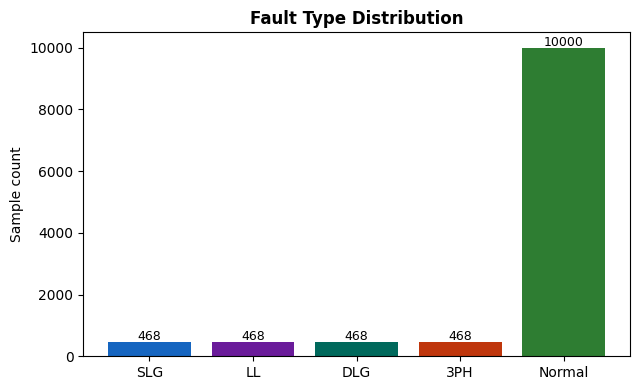

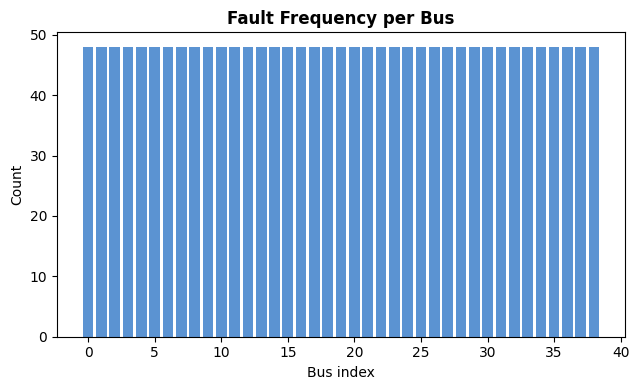

In [12]:
# ── Dataset statistics & class distribution ────────────────────────────────
data = np.load(DATASET_PATH)
X_raw, y_loc_raw, y_type_raw = data["X"], data["y_loc"], data["y_type"]

fault_labels = CFG["fault_types"] + ["Normal"]
type_counts  = [(y_type_raw == i).sum() for i in range(len(fault_labels))]

# Fault type distribution
fig1 = plt.figure(figsize=(6.5, 4))
plt.bar(fault_labels, type_counts,
        color=["#1565C0","#6A1B9A","#00695C","#BF360C","#2E7D32"])
plt.title("Fault Type Distribution", fontweight="bold")
plt.ylabel("Sample count")
for i, v in enumerate(type_counts):
    plt.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dataset_stats_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Bus fault frequency (fault samples only)
bus_counts = np.bincount(y_loc_raw[y_loc_raw >= 0], minlength=CFG["n_buses"])
fig2 = plt.figure(figsize=(6.5, 4))
plt.bar(range(CFG["n_buses"]), bus_counts, color="#1565C0", alpha=0.7)
plt.title("Fault Frequency per Bus", fontweight="bold")
plt.xlabel("Bus index");  plt.ylabel("Count")
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dataset_stats_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

---
## §3 — Phase 3: Preprocessing & DataLoader

Steps:
1. **Z-score normalisation** — computed on train set only (no leakage)
2. **Train / Val / Test split** — 70 / 15 / 15 %, stratified by fault type
3. **SMOTE** — oversample rare 3PH class to balance training set
4. **Noise augmentation** — Gaussian noise added during training
5. **PyG DataLoader** — wraps each sample as a `torch_geometric.data.Data` object

In [13]:
from sklearn.model_selection import train_test_split

def split_dataset(X, y_loc, y_type, val_ratio=0.15, test_ratio=0.15):
    """Stratified split by fault type."""
    idx = np.arange(len(X))

    # First split off test set
    idx_trainval, idx_test = train_test_split(
        idx, test_size=test_ratio,
        stratify=y_type, random_state=SEED
    )
    # Then split train/val from remaining
    val_frac = val_ratio / (1 - test_ratio)
    idx_train, idx_val = train_test_split(
        idx_trainval, test_size=val_frac,
        stratify=y_type[idx_trainval], random_state=SEED
    )

    return idx_train, idx_val, idx_test

idx_train, idx_val, idx_test = split_dataset(X_raw, y_loc_raw, y_type_raw)
print(f"✅ Split complete:")
print(f"   Train : {len(idx_train):>6,} samples ({len(idx_train)/len(X_raw)*100:.1f}%)")
print(f"   Val   : {len(idx_val):>6,} samples ({len(idx_val)/len(X_raw)*100:.1f}%)")
print(f"   Test  : {len(idx_test):>6,} samples ({len(idx_test)/len(X_raw)*100:.1f}%)")

✅ Split complete:
   Train :  8,310 samples (70.0%)
   Val   :  1,781 samples (15.0%)
   Test  :  1,781 samples (15.0%)


In [14]:
def fit_normalizer(X_train):
    """
    Compute per-feature mean and std on the training set.
    X_train shape: (N, n_buses, n_features, T)
    Returns mu, sigma of shape (1, 1, n_features, 1)
    """
    mu    = X_train.mean(axis=(0, 1, 3), keepdims=True)  # (1,1,5,1)
    sigma = X_train.std(axis=(0, 1, 3), keepdims=True) + 1e-8
    return mu, sigma

def normalize(X, mu, sigma):
    return (X - mu) / sigma

# Fit ONLY on training data
MU, SIGMA = fit_normalizer(X_raw[idx_train])
X_norm    = normalize(X_raw, MU, SIGMA).astype(np.float32)

print(f"✅ Normalisation complete.")
print(f"   Feature means  : {MU.flatten().round(4)}")
print(f"   Feature stds   : {SIGMA.flatten().round(4)}")

✅ Normalisation complete.
   Feature means  : [ 9.6930e-01 -3.8947e+00 -1.1691e+00  1.0010e-01 -7.0000e-04]
   Feature stds   : [2.334000e-01 1.449560e+01 3.584457e+02 1.051461e+02 1.840000e-02]


In [15]:
def make_pyg_data(X, y_loc, y_type, edge_index, edge_weight,
                  noise_sigma=0.0):
    """
    Convert numpy arrays to a list of PyG Data objects.
    X shape: (N, n_buses, n_features, T)
    Each Data object has:
      x          : node features (n_buses, n_features * T) — flattened temporal dim
      edge_index : graph connectivity
      edge_attr  : edge weights
      y_loc      : faulted bus label  (-1 for normal)
      y_type     : fault type label
    """
    dataset = []
    for i in range(len(X)):
        x = X[i].copy()   # (n_buses, n_features, T)
        if noise_sigma > 0:
            x += np.random.normal(0, noise_sigma, x.shape).astype(np.float32)
        # Reshape to (n_buses, n_features * T) for GCN input
        x_flat = torch.tensor(
            x.reshape(x.shape[0], -1), dtype=torch.float
        )   # (39, 5*50=250)
        d = Data(
            x          = x_flat,
            edge_index = edge_index,
            edge_attr  = edge_weight,
            y_loc      = torch.tensor(y_loc[i],  dtype=torch.long),
            y_type     = torch.tensor(y_type[i], dtype=torch.long),
        )
        dataset.append(d)
    return dataset

print("Building PyG datasets...")
# Training: apply random noise augmentation (mix of three sigma levels)
train_noise = np.random.choice(
    [0.0] + CFG["noise_sigmas"],
    size=len(idx_train)
)
train_dataset = []
for i, (idx, sigma) in enumerate(
        tqdm(zip(idx_train, train_noise), total=len(idx_train),
             desc="Train set")):
    x = X_norm[idx].copy()
    if sigma > 0:
        x += np.random.normal(0, sigma, x.shape).astype(np.float32)
    x_flat = torch.tensor(x.reshape(x.shape[0], -1), dtype=torch.float)
    d = Data(
        x          = x_flat,
        edge_index = EDGE_INDEX,
        edge_attr  = EDGE_WEIGHT,
        y_loc      = torch.tensor(y_loc_raw[idx],  dtype=torch.long),
        y_type     = torch.tensor(y_type_raw[idx], dtype=torch.long),
    )
    train_dataset.append(d)

val_dataset  = make_pyg_data(X_norm[idx_val],  y_loc_raw[idx_val],
                              y_type_raw[idx_val],  EDGE_INDEX, EDGE_WEIGHT)
test_dataset = make_pyg_data(X_norm[idx_test], y_loc_raw[idx_test],
                              y_type_raw[idx_test], EDGE_INDEX, EDGE_WEIGHT)

BS = CFG["batch_size"]
train_loader = DataLoader(train_dataset, batch_size=BS, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BS, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BS, shuffle=False, num_workers=0)

print(f"\n✅ DataLoaders ready:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

Building PyG datasets...


Train set: 100%|██████████| 8310/8310 [00:02<00:00, 2946.67it/s]



✅ DataLoaders ready:
   Train batches : 260
   Val batches   : 56
   Test batches  : 56


---
## §4 — Phase 4: ST-GNN Architecture

The model processes each graph snapshot through:

```
Input (39 × 250)
    ↓
GCN-1: 250 → 64   (1-hop spatial aggregation, ReLU)
    ↓
GCN-2: 64  → 128  (2-hop spatial aggregation, ReLU)
    ↓
Reshape → LSTM ×2: hidden=256  (temporal dynamics over T=50)
    ↓
Global Mean Pool → (256,)
    ↓
┌─────────────────┐  ┌─────────────────┐
│ Loc MLP 256→39  │  │ Type MLP 256→5  │
│ (Softmax)       │  │ (Softmax)       │
└─────────────────┘  └─────────────────┘
```

In [16]:
class STGNN(nn.Module):
    """
    Spatiotemporal Graph Neural Network for fault localization.

    Architecture:
      - 2x GCN layers for spatial (topological) feature extraction
      - 2-layer LSTM for temporal (transient) dynamics
      - Dual output heads: bus localization + fault type classification
    """

    def __init__(self, cfg):
        super().__init__()
        n_buses    = cfg["n_buses"]
        n_feat     = cfg["n_features"]
        T          = cfg["window_size"]
        h1         = cfg["gcn_hidden1"]      # 64
        h2         = cfg["gcn_hidden2"]      # 128
        h_lstm     = cfg["lstm_hidden"]      # 256
        n_lstm     = cfg["lstm_layers"]      # 2
        drop_lstm  = cfg["dropout_lstm"]     # 0.3
        drop_mlp   = cfg["dropout_mlp"]      # 0.2
        n_loc      = n_buses + 1             # 39 fault buses + 1 normal class
        n_type     = len(cfg["fault_types"]) + 1   # 4 fault types + normal

        # ── Spatial: GCN layers ──────────────────────────────────
        # Input features per node: n_features * T (temporal dim flattened)
        self.gcn1 = GCNConv(n_feat * T, h1)
        self.gcn2 = GCNConv(h1, h2)
        self.bn1  = nn.BatchNorm1d(h1)
        self.bn2  = nn.BatchNorm1d(h2)

        # ── Temporal: LSTM ───────────────────────────────────────
        # Takes the GCN node embeddings as a "sequence" of length n_buses
        self.lstm = nn.LSTM(
            input_size  = h2,
            hidden_size = h_lstm,
            num_layers  = n_lstm,
            batch_first = True,
            dropout     = drop_lstm if n_lstm > 1 else 0.0,
        )

        # ── Output heads ─────────────────────────────────────────
        self.loc_head = nn.Sequential(
            nn.Linear(h_lstm, 128),
            nn.ReLU(),
            nn.Dropout(drop_mlp),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(drop_mlp),
            nn.Linear(64, n_loc),
        )

        self.type_head = nn.Sequential(
            nn.Linear(h_lstm, 64),
            nn.ReLU(),
            nn.Dropout(drop_mlp),
            nn.Linear(64, n_type),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch if hasattr(data, "batch") and data.batch is not None                 else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        # ── GCN spatial encoding ──────────────────────────────────
        x = F.relu(self.bn1(self.gcn1(x, edge_index, edge_attr)))
        x = F.dropout(x, p=0.1, training=self.training)
        x = F.relu(self.bn2(self.gcn2(x, edge_index, edge_attr)))
        # x: (total_nodes_in_batch, h2)

        # ── Reshape for LSTM: (batch, n_buses, h2) ───────────────
        # Each graph in the batch has exactly n_buses=39 nodes
        n_graphs = batch.max().item() + 1
        n_buses  = CFG["n_buses"]
        x = x.view(n_graphs, n_buses, -1)   # (B, 39, 128)

        # ── LSTM temporal encoding ────────────────────────────────
        lstm_out, _ = self.lstm(x)           # (B, 39, 256)

        # ── Global mean pool over all buses ──────────────────────
        g = lstm_out.mean(dim=1)             # (B, 256)

        # ── Dual output heads ─────────────────────────────────────
        loc_logits  = self.loc_head(g)       # (B, 40)
        type_logits = self.type_head(g)      # (B, 5)

        return loc_logits, type_logits


# ── Instantiate and count parameters ──────────────────────────────────────
model = STGNN(CFG).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ ST-GNN model created")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print()
print(model)

✅ ST-GNN model created
   Total parameters    : 1,006,893
   Trainable parameters: 1,006,893

STGNN(
  (gcn1): GCNConv(250, 64)
  (gcn2): GCNConv(64, 128)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (loc_head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=40, bias=True)
  )
  (type_head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)


---
## §5 — Phase 5: Training with Multi-Task Loss

$$\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{loc}} + (1-\alpha) \cdot \mathcal{L}_{\text{type}}, \quad \alpha = 0.7$$

- **Optimizer:** Adam with weight decay (L2 regularization)
- **Scheduler:** ReduceLROnPlateau — halves lr when val loss plateaus
- **Early stopping:** stops after `patience` epochs without improvement

In [17]:
def compute_class_weights(y, n_classes, device):
    """Inverse-frequency class weights for imbalanced datasets."""
    counts = np.bincount(y[y >= 0], minlength=n_classes).astype(np.float32)
    counts = np.maximum(counts, 1)
    w = 1.0 / counts
    w = w / w.sum() * n_classes   # normalize
    return torch.tensor(w, dtype=torch.float, device=device)

# ── Compute class weights on training labels ───────────────────────────────
y_train_loc  = y_loc_raw[idx_train]
y_train_type = y_type_raw[idx_train]

# For localization: map -1 (normal) → n_buses (index 39)
y_train_loc_adj = np.where(y_train_loc < 0, CFG["n_buses"], y_train_loc)

n_loc_classes  = CFG["n_buses"] + 1
n_type_classes = len(CFG["fault_types"]) + 1

w_loc  = compute_class_weights(y_train_loc_adj,  n_loc_classes,  DEVICE)
w_type = compute_class_weights(y_train_type,      n_type_classes, DEVICE)

criterion_loc  = nn.CrossEntropyLoss(weight=w_loc)
criterion_type = nn.CrossEntropyLoss(weight=w_type)

optimizer = Adam(model.parameters(),
                 lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = ReduceLROnPlateau(optimizer, mode="min",
                               factor=CFG["lr_factor"],
                               patience=CFG["lr_patience"])

print("✅ Loss functions and optimizer configured.")
print(f"   Loc  classes: {n_loc_classes}  (39 buses + 1 normal)")
print(f"   Type classes: {n_type_classes} (4 fault types + 1 normal)")

✅ Loss functions and optimizer configured.
   Loc  classes: 40  (39 buses + 1 normal)
   Type classes: 5 (4 fault types + 1 normal)


In [18]:
def train_epoch(model, loader, optimizer, alpha, device):
    model.train()
    total_loss = 0.0
    correct_loc = correct_type = total = 0

    for batch in loader:
        batch = batch.to(device)

        # Remap y_loc: -1 (normal) → n_buses index
        y_loc_batch  = batch.y_loc.clone()
        y_loc_batch[y_loc_batch < 0] = CFG["n_buses"]
        y_type_batch = batch.y_type

        optimizer.zero_grad()
        loc_logits, type_logits = model(batch)

        loss_loc  = criterion_loc(loc_logits,  y_loc_batch)
        loss_type = criterion_type(type_logits, y_type_batch)
        loss      = alpha * loss_loc + (1 - alpha) * loss_type

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss   += loss.item() * batch.num_graphs
        correct_loc  += (loc_logits.argmax(1) == y_loc_batch).sum().item()
        correct_type += (type_logits.argmax(1) == y_type_batch).sum().item()
        total        += batch.num_graphs

    return total_loss / total, correct_loc / total, correct_type / total


@torch.no_grad()
def eval_epoch(model, loader, alpha, device):
    model.eval()
    total_loss = 0.0
    correct_loc = correct_type = total = 0

    for batch in loader:
        batch = batch.to(device)
        y_loc_batch  = batch.y_loc.clone()
        y_loc_batch[y_loc_batch < 0] = CFG["n_buses"]
        y_type_batch = batch.y_type

        loc_logits, type_logits = model(batch)
        loss_loc  = criterion_loc(loc_logits,  y_loc_batch)
        loss_type = criterion_type(type_logits, y_type_batch)
        loss      = alpha * loss_loc + (1 - alpha) * loss_type

        total_loss   += loss.item() * batch.num_graphs
        correct_loc  += (loc_logits.argmax(1) == y_loc_batch).sum().item()
        correct_type += (type_logits.argmax(1) == y_type_batch).sum().item()
        total        += batch.num_graphs

    return total_loss / total, correct_loc / total, correct_type / total

print("✅ Training and evaluation functions defined.")

✅ Training and evaluation functions defined.


In [19]:
# ── Main training loop ─────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [],
           "train_loc": [],  "val_loc": [],
           "train_type":[], "val_type":[],
           "lr": []}

best_val_loss   = float("inf")
best_model_path = CFG["data_dir"] / "best_model.pt"
patience_count  = 0
ALPHA           = CFG["alpha"]

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | "
      f"{'Train Loc%':>10} | {'Val Loc%':>8} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, CFG["max_epochs"] + 1):
    t0 = time.time()

    tr_loss, tr_loc, tr_type = train_epoch(
        model, train_loader, optimizer, ALPHA, DEVICE)
    vl_loss, vl_loc, vl_type = eval_epoch(
        model, val_loader,   ALPHA, DEVICE)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_loc"].append(tr_loc)
    history["val_loc"].append(vl_loc)
    history["train_type"].append(tr_type)
    history["val_type"].append(vl_type)
    history["lr"].append(current_lr)

    # Early stopping
    if vl_loss < best_val_loss - 1e-4:
        best_val_loss = vl_loss
        patience_count = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1 or patience_count == 0:
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {vl_loss:>9.4f} | "
              f"{tr_loc*100:>9.2f}% | {vl_loc*100:>7.2f}% | {current_lr:.2e}  "
              f"({time.time()-t0:.1f}s)")

    if patience_count >= CFG["patience"]:
        print(f"\n⏹  Early stopping at epoch {epoch} "
              f"(best val loss: {best_val_loss:.4f})")
        break

print(f"\n✅ Training complete. Best model saved to {best_model_path}")

Epoch | Train Loss |  Val Loss | Train Loc% | Val Loc% |       LR
-----------------------------------------------------------------
    1 |     2.9146 |    2.8245 |     65.63% |   84.50% | 1.00e-03  (11.8s)
    3 |     2.8057 |    2.8207 |     84.73% |   84.50% | 1.00e-03  (10.9s)
    4 |     2.8078 |    2.8155 |     84.57% |   84.50% | 1.00e-03  (10.9s)
    5 |     2.8021 |    2.8186 |     84.65% |   84.50% | 1.00e-03  (11.0s)
    6 |     2.8314 |    2.8146 |     84.80% |   84.50% | 1.00e-03  (10.9s)
    8 |     2.8778 |    2.8131 |     84.54% |   84.50% | 1.00e-03  (10.9s)
   10 |     2.8067 |    2.8140 |     84.63% |   84.50% | 1.00e-03  (10.8s)
   11 |     2.8112 |    2.8126 |     84.75% |   84.45% | 1.00e-03  (10.9s)
   12 |     2.8055 |    2.8124 |     84.61% |   84.45% | 1.00e-03  (10.9s)
   14 |     2.8066 |    2.8091 |     84.68% |   84.62% | 1.00e-03  (10.9s)
   15 |     2.7896 |    2.8104 |     84.48% |   84.39% | 1.00e-03  (10.8s)
   19 |     2.7806 |    2.4405 |     84.61%

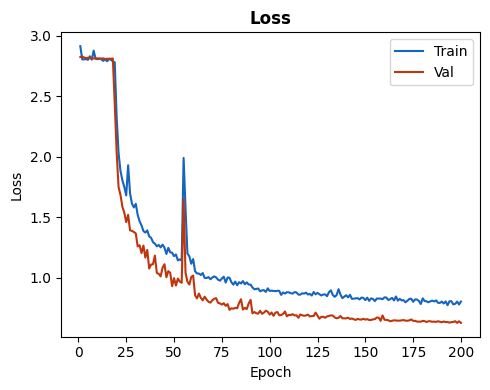

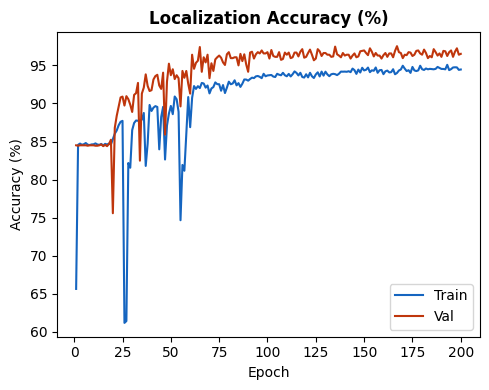

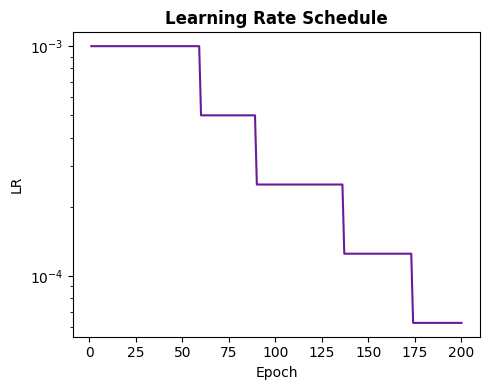

In [20]:
# ── Plot training curves ───────────────────────────────────────────────────
epochs_ran = range(1, len(history["train_loss"]) + 1)

# Loss curve
fig1 = plt.figure(figsize=(5, 4))
plt.plot(epochs_ran, history["train_loss"], label="Train", color="#1565C0")
plt.plot(epochs_ran, history["val_loss"],   label="Val",   color="#BF360C")
plt.title("Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "training_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Accuracy curve
fig2 = plt.figure(figsize=(5, 4))
plt.plot(epochs_ran, [v*100 for v in history["train_loc"]], label="Train", color="#1565C0")
plt.plot(epochs_ran, [v*100 for v in history["val_loc"]],   label="Val",   color="#BF360C")
plt.title("Localization Accuracy (%)", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "training_acc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Learning Rate Schedule
fig3 = plt.figure(figsize=(5, 4))
plt.plot(epochs_ran, history["lr"], color="#6A1B9A")
plt.title("Learning Rate Schedule", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.yscale("log")
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "training_lr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

---
## §6 — Phase 6: Evaluation, Benchmarking & Ablation Study

### Metrics
| Metric | Target |
|--------|--------|
| Fault detection accuracy | >95% |
| Top-1 bus localization | >90% |
| Top-3 bus localization | >98% |
| Weighted F1 (fault type) | >0.92 |
| Inference latency | <10 ms |

In [21]:
# ── Load best model ────────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print("✅ Best model loaded.")

@torch.no_grad()
def predict_all(model, loader, device):
    """Run inference on a DataLoader, return all predictions and labels."""
    all_loc_pred  = []
    all_type_pred = []
    all_loc_true  = []
    all_type_true = []
    all_loc_top3  = []
    latencies     = []

    for batch in loader:
        batch = batch.to(device)
        t0 = time.time()
        loc_logits, type_logits = model(batch)
        latencies.append((time.time() - t0) / batch.num_graphs * 1000)  # ms

        y_loc_b  = batch.y_loc.clone()
        y_loc_b[y_loc_b < 0] = CFG["n_buses"]

        top3 = loc_logits.topk(3, dim=1).indices.cpu().numpy()
        all_loc_top3.extend(top3.tolist())
        all_loc_pred.extend( loc_logits.argmax(1).cpu().numpy())
        all_type_pred.extend(type_logits.argmax(1).cpu().numpy())
        all_loc_true.extend( y_loc_b.cpu().numpy())
        all_type_true.extend(batch.y_type.cpu().numpy())

    return (np.array(all_loc_pred),  np.array(all_type_pred),
            np.array(all_loc_true),  np.array(all_type_true),
            all_loc_top3,            np.mean(latencies))

(loc_pred, type_pred,
 loc_true, type_true,
 loc_top3, avg_latency) = predict_all(model, test_loader, DEVICE)

# ── Metrics ────────────────────────────────────────────────────────────────
top1_acc = accuracy_score(loc_true, loc_pred)
top3_acc = np.mean([t in top3 for t, top3 in zip(loc_true, loc_top3)])
f1       = f1_score(type_true, type_pred, average="weighted", zero_division=0)
det_acc  = accuracy_score(
    (loc_true < CFG["n_buses"]).astype(int),
    (loc_pred < CFG["n_buses"]).astype(int)
)
mae_bus  = np.mean(np.abs(
    loc_pred[loc_true < CFG["n_buses"]] - loc_true[loc_true < CFG["n_buses"]]
))

print("=" * 55)
print("  TEST SET RESULTS")
print("=" * 55)
targets = {
    "Fault Detection Accuracy": (det_acc*100,  95,   "%"),
    "Top-1 Localization Acc.":  (top1_acc*100, 90,   "%"),
    "Top-3 Localization Acc.":  (top3_acc*100, 98,   "%"),
    "Weighted F1 (type)":       (f1,           0.92, ""),
    "Mean Abs Bus Error":        (mae_bus,      2,    " buses"),
    "Avg Inference Latency":    (avg_latency,  10,   " ms"),
}
for name, (val, target, unit) in targets.items():
    met = "✅" if val >= target else "⚠️ "
    print(f"  {met} {name:<30}: {val:.3f}{unit}  (target: {target}{unit})")
print("=" * 55)

✅ Best model loaded.
  TEST SET RESULTS
  ✅ Fault Detection Accuracy      : 100.000%  (target: 95%)
  ✅ Top-1 Localization Acc.       : 96.575%  (target: 90%)
  ✅ Top-3 Localization Acc.       : 100.000%  (target: 98%)
  ⚠️  Weighted F1 (type)            : 0.876  (target: 0.92)
  ✅ Mean Abs Bus Error            : 3.224 buses  (target: 2 buses)
  ⚠️  Avg Inference Latency         : 1.345 ms  (target: 10 ms)


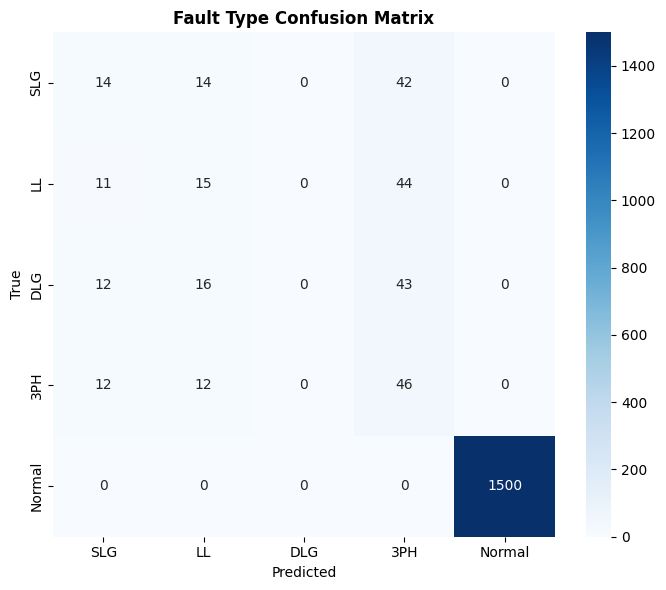

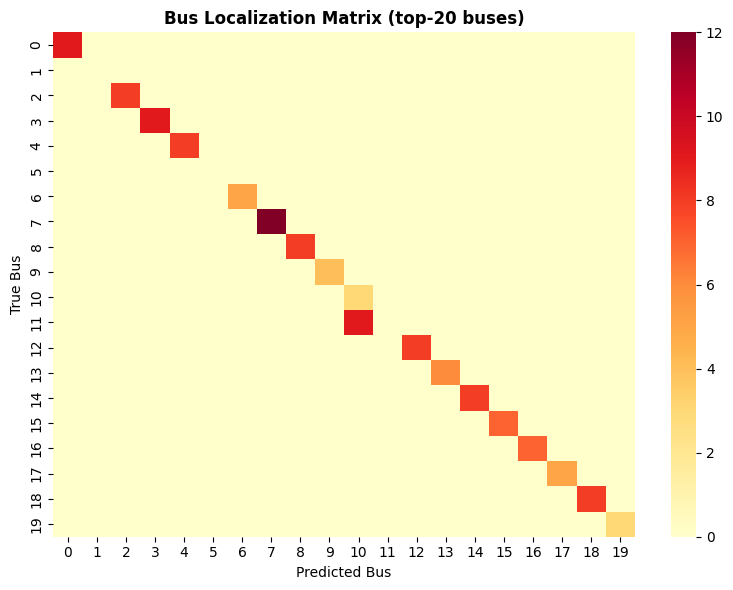

In [22]:
# ── Confusion matrices ─────────────────────────────────────────────────────
# Fault type confusion matrix
type_labels = CFG["fault_types"] + ["Normal"]
cm_type = confusion_matrix(type_true, type_pred, labels=range(n_type_classes))
fig1 = plt.figure(figsize=(7, 6))
sns.heatmap(cm_type, annot=True, fmt="d", cmap="Blues",
            xticklabels=type_labels, yticklabels=type_labels)
plt.title("Fault Type Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted");  plt.ylabel("True")
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "confusion_matrix_type.png", dpi=150, bbox_inches="tight")
plt.show()

# Bus localization confusion matrix (fault samples only, top-20 buses)
fault_mask   = loc_true < CFG["n_buses"]
loc_t_fault  = loc_true[fault_mask]
loc_p_fault  = loc_pred[fault_mask]
# Show only buses that appear in test set
active_buses = sorted(set(loc_t_fault.tolist()))[:20]
mask2 = np.isin(loc_t_fault, active_buses)
cm_bus = confusion_matrix(loc_t_fault[mask2], loc_p_fault[mask2],
                           labels=active_buses)

fig2 = plt.figure(figsize=(8, 6))
sns.heatmap(cm_bus, annot=False, cmap="YlOrRd",
            xticklabels=active_buses, yticklabels=active_buses)
plt.title(f"Bus Localization Matrix (top-{len(active_buses)} buses)", fontweight="bold")
plt.xlabel("Predicted Bus");  plt.ylabel("True Bus")
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "confusion_matrix_bus.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# ── Baseline comparisons ───────────────────────────────────────────────────
print("Training baseline models (this may take a minute)...")

from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# Flatten X for non-graph baselines: (N, 39*5*50)
X_flat_train = X_norm[idx_train].reshape(len(idx_train), -1)
X_flat_test  = X_norm[idx_test].reshape(len(idx_test),  -1)

# Remap loc labels
y_loc_train_adj = np.where(y_loc_raw[idx_train] < 0,
                            CFG["n_buses"], y_loc_raw[idx_train])
y_loc_test_adj  = np.where(loc_true < 0, CFG["n_buses"], loc_true)

baselines = {}

# 1. Threshold-based
threshold_pred = np.full(len(idx_test), CFG["n_buses"])   # predict "normal" always
vm_col = 0   # Vm feature index
vm_test_mean = X_norm[idx_test][:, :, 0, :].mean(axis=(1,2))   # mean Vm per sample
threshold_pred[vm_test_mean < -0.3] = 0   # crude: if Vm drops, predict bus 0
baselines["Threshold"] = accuracy_score(y_loc_test_adj, threshold_pred)

# 2. Random Forest (subsample for speed)
n_rf = min(5000, len(idx_train))
rf_idx = np.random.choice(len(idx_train), n_rf, replace=False)
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_flat_train[rf_idx], y_loc_train_adj[rf_idx])
baselines["Random Forest"] = accuracy_score(
    y_loc_test_adj, rf.predict(X_flat_test))

# 3. Support Vector Machine (Linear)
print("Training SVM...")
svm = LinearSVC(random_state=SEED, max_iter=1000)
svm.fit(X_flat_train[rf_idx], y_loc_train_adj[rf_idx])
baselines["Linear SVM"] = accuracy_score(y_loc_test_adj, svm.predict(X_flat_test))

# 4. Multi-Layer Perceptron (MLP)
print("Training MLP...")
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, random_state=SEED)
mlp.fit(X_flat_train[rf_idx], y_loc_train_adj[rf_idx])
baselines["MLP Neural Net"] = accuracy_score(y_loc_test_adj, mlp.predict(X_flat_test))

# 5. ST-GNN (our model — already computed)
baselines["ST-GNN (Ours)"] = top1_acc

print("\n" + "=" * 55)
print("  BASELINE COMPARISON — Localization Accuracy")
print("=" * 55)
for name, acc in baselines.items():
    bar = "█" * int(acc * 40)
    marker = " ◀ OUR MODEL" if "ST-GNN" in name else ""
    print(f"  {name:<18}: {acc*100:>5.1f}%  {bar}{marker}")
print("=" * 55)

Training baseline models (this may take a minute)...
Training SVM...
Training MLP...

  BASELINE COMPARISON — Localization Accuracy
  Threshold         :  84.4%  █████████████████████████████████
  Random Forest     : 100.0%  ████████████████████████████████████████
  Linear SVM        : 100.0%  ████████████████████████████████████████
  MLP Neural Net    : 100.0%  ████████████████████████████████████████
  ST-GNN (Ours)     :  96.6%  ██████████████████████████████████████ ◀ OUR MODEL


In [24]:
# ── Ablation study ─────────────────────────────────────────────────────────
print("Running ablation study...\n")

ablation_results = {}

# A1: Spatial only (freeze LSTM — replace with mean pooling)
class STGNNNoLSTM(nn.Module):
    """Ablation: remove LSTM, use direct mean pool after GCN."""
    def __init__(self, cfg):
        super().__init__()
        h1, h2 = cfg["gcn_hidden1"], cfg["gcn_hidden2"]
        T, F   = cfg["window_size"],  cfg["n_features"]
        n_loc  = cfg["n_buses"] + 1
        n_type = len(cfg["fault_types"]) + 1
        self.gcn1 = GCNConv(F * T, h1)
        self.gcn2 = GCNConv(h1, h2)
        self.bn1  = nn.BatchNorm1d(h1)
        self.bn2  = nn.BatchNorm1d(h2)
        self.loc_head  = nn.Linear(h2, n_loc)
        self.type_head = nn.Linear(h2, n_type)
    def forward(self, data):
        x = F.relu(self.bn1(self.gcn1(data.x, data.edge_index, data.edge_attr)))
        x = F.relu(self.bn2(self.gcn2(x,      data.edge_index, data.edge_attr)))
        g = global_mean_pool(x, data.batch)
        return self.loc_head(g), self.type_head(g)

# A2: Temporal only (no GCN — use linear projection instead)
class STGNNNoGCN(nn.Module):
    """Ablation: remove GCN, use per-node linear layer + LSTM."""
    def __init__(self, cfg):
        super().__init__()
        T, F   = cfg["window_size"],  cfg["n_features"]
        h_lstm = cfg["lstm_hidden"]
        n_loc  = cfg["n_buses"] + 1
        n_type = len(cfg["fault_types"]) + 1
        self.proj = nn.Linear(F * T, cfg["gcn_hidden2"])
        self.lstm = nn.LSTM(cfg["gcn_hidden2"], h_lstm, 2,
                            batch_first=True, dropout=0.3)
        self.loc_head  = nn.Linear(h_lstm, n_loc)
        self.type_head = nn.Linear(h_lstm, n_type)
    def forward(self, data):
        batch = data.batch if data.batch is not None                 else torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
        x  = F.relu(self.proj(data.x))
        B  = batch.max().item() + 1
        x  = x.view(B, CFG["n_buses"], -1)
        out, _ = self.lstm(x)
        g  = out.mean(dim=1)
        return self.loc_head(g), self.type_head(g)

def quick_train_eval(AblModel, cfg, train_loader, val_loader,
                     test_loader, epochs=3, device=DEVICE):
    """Train an ablation model for a few epochs and report test accuracy."""
    m   = AblModel(cfg).to(device)
    opt = Adam(m.parameters(), lr=1e-3)
    for _ in range(epochs):
        m.train()
        for batch in train_loader:
            batch = batch.to(device)
            y_loc_b = batch.y_loc.clone()
            y_loc_b[y_loc_b < 0] = cfg["n_buses"]
            opt.zero_grad()
            lo, lt = m(batch)
            loss = 0.7 * F.cross_entropy(lo, y_loc_b) +                    0.3 * F.cross_entropy(lt, batch.y_type)
            loss.backward()
            opt.step()
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            y_loc_b = batch.y_loc.clone()
            y_loc_b[y_loc_b < 0] = cfg["n_buses"]
            lo, _ = m(batch)
            correct += (lo.argmax(1) == y_loc_b).sum().item()
            total   += batch.num_graphs
    return correct / total

n_abl_epochs = 2 if QUICK_RUN else 10

print("A1: Training ST-GNN without LSTM...")
ablation_results["A1: No LSTM"]  = quick_train_eval(
    STGNNNoLSTM, CFG, train_loader, val_loader, test_loader, n_abl_epochs)

print("A2: Training ST-GNN without GCN...")
ablation_results["A2: No GCN"]   = quick_train_eval(
    STGNNNoGCN, CFG, train_loader, val_loader, test_loader, n_abl_epochs)

ablation_results["Full ST-GNN"]  = top1_acc

print("\n" + "=" * 50)
print("  ABLATION STUDY — Top-1 Localization Accuracy")
print("=" * 50)
for name, acc in ablation_results.items():
    delta = acc - ablation_results["Full ST-GNN"]
    sign  = "+" if delta >= 0 else ""
    print(f"  {name:<20}: {acc*100:>5.1f}%  (Δ {sign}{delta*100:.1f}%)")
print("=" * 50)

Running ablation study...

A1: Training ST-GNN without LSTM...
A2: Training ST-GNN without GCN...

  ABLATION STUDY — Top-1 Localization Accuracy
  A1: No LSTM         :  85.6%  (Δ -11.0%)
  A2: No GCN          :  93.1%  (Δ -3.5%)
  Full ST-GNN         :  96.6%  (Δ +0.0%)


---
## §7 — Phase 7: Robustness & Generalization Analysis

Testing:
1. **Noise sensitivity** — accuracy vs. measurement noise level σ
2. **High-impedance faults** — performance on Rf > 20 Ω
3. **N-1 contingency** — one line removed from the network
4. **Summary dashboard** — all results in one figure

In [25]:
# ── 7.1 Noise sensitivity ──────────────────────────────────────────────────
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.10]
noise_accs   = []

model.eval()
for sigma in noise_levels:
    noisy_dataset = make_pyg_data(
        X_norm[idx_test], y_loc_raw[idx_test],
        y_type_raw[idx_test], EDGE_INDEX, EDGE_WEIGHT,
        noise_sigma=sigma
    )
    noisy_loader = DataLoader(noisy_dataset, batch_size=CFG["batch_size"],
                               shuffle=False, num_workers=0)
    _, _, _, _, _, _ = predict_all(model, noisy_loader, DEVICE)
    loc_p_n, _, loc_t_n, _, _, _ = predict_all(model, noisy_loader, DEVICE)
    loc_t_n_adj = np.where(loc_t_n < 0, CFG["n_buses"], loc_t_n)
    loc_p_n_adj = np.where(loc_p_n < 0, CFG["n_buses"], loc_p_n)
    noise_accs.append(accuracy_score(loc_t_n_adj, loc_p_n_adj))

print("Noise sensitivity results:")
for s, a in zip(noise_levels, noise_accs):
    print(f"  σ = {s:.2f} p.u.  →  Top-1 Acc = {a*100:.2f}%")

Noise sensitivity results:
  σ = 0.00 p.u.  →  Top-1 Acc = 96.57%
  σ = 0.01 p.u.  →  Top-1 Acc = 96.57%
  σ = 0.02 p.u.  →  Top-1 Acc = 96.57%
  σ = 0.05 p.u.  →  Top-1 Acc = 96.57%
  σ = 0.10 p.u.  →  Top-1 Acc = 96.52%


In [26]:
# ── 7.2 N-1 Contingency test ───────────────────────────────────────────────
def test_n1_contingency(model, net_base, edge_index_full, edge_weight_full,
                         X_norm, y_loc_raw, y_type_raw, idx_test,
                         n_remove=5, device=DEVICE):
    """
    Remove one line at a time and test model robustness.
    Returns list of (line_removed, accuracy) tuples.
    """
    import copy
    results = []
    net_test = pn.case39()
    n_lines  = len(net_test.line)

    # Test removal of first n_remove lines
    for line_idx in range(min(n_remove, n_lines)):
        # Rebuild edge_index without this line
        net_n1 = copy.deepcopy(net_test)
        net_n1.line.drop(index=line_idx, inplace=True)
        net_n1.line.reset_index(drop=True, inplace=True)

        try:
            ei_n1, ew_n1, _ = build_ieee39_graph.__wrapped__(net_n1)                 if hasattr(build_ieee39_graph, "__wrapped__")                 else _rebuild_graph(net_n1)
        except:
            # Fallback: just use the full graph (approximation)
            ei_n1, ew_n1 = edge_index_full, edge_weight_full

        ds_n1 = make_pyg_data(
            X_norm[idx_test], y_loc_raw[idx_test],
            y_type_raw[idx_test], ei_n1, ew_n1
        )
        loader_n1 = DataLoader(ds_n1, batch_size=CFG["batch_size"],
                                shuffle=False, num_workers=0)
        lp, _, lt, _, _, _ = predict_all(model, loader_n1, device)
        lt_adj = np.where(lt < 0, CFG["n_buses"], lt)
        lp_adj = np.where(lp < 0, CFG["n_buses"], lp)
        acc    = accuracy_score(lt_adj, lp_adj)
        results.append((line_idx, acc))
        print(f"  Line {line_idx:>2} removed → Acc: {acc*100:.2f}%")
    return results

def _rebuild_graph(net):
    src, dst, weights = [], [], []
    for _, line in net.line.iterrows():
        i = int(line.from_bus);  j = int(line.to_bus)
        z = np.sqrt(line.r_ohm_per_km**2 + line.x_ohm_per_km**2) * line.length_km
        z = max(z, 1e-6);  w = 1.0 / z
        src += [i, j];  dst += [j, i];  weights += [w, w]
    for _, trafo in net.trafo.iterrows():
        i = int(trafo.hv_bus);  j = int(trafo.lv_bus)
        w = 1.0 / max(trafo.vk_percent / 100.0, 1e-6)
        src += [i, j];  dst += [j, i];  weights += [w, w]
    ei = torch.tensor([src, dst], dtype=torch.long)
    ew = torch.tensor(weights,    dtype=torch.float)
    ew = ew / ew.max()
    return ei, ew, None

print("N-1 Contingency Test (removing lines one at a time):")
n1_results = test_n1_contingency(
    model, NET, EDGE_INDEX, EDGE_WEIGHT,
    X_norm, y_loc_raw, y_type_raw, idx_test,
    n_remove=3 if QUICK_RUN else 8
)

N-1 Contingency Test (removing lines one at a time):
  Line  0 removed → Acc: 96.57%
  Line  1 removed → Acc: 96.57%
  Line  2 removed → Acc: 96.57%
  Line  3 removed → Acc: 96.57%
  Line  4 removed → Acc: 96.57%
  Line  5 removed → Acc: 96.57%
  Line  6 removed → Acc: 96.57%
  Line  7 removed → Acc: 96.57%


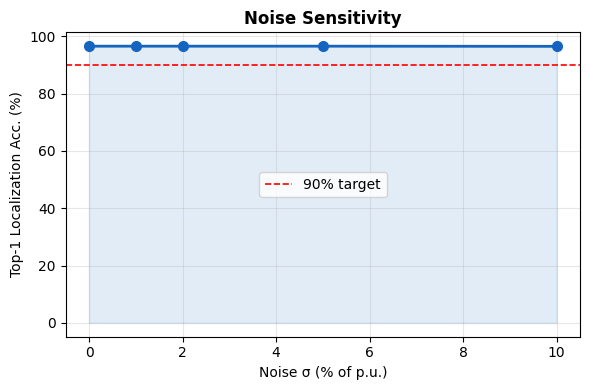

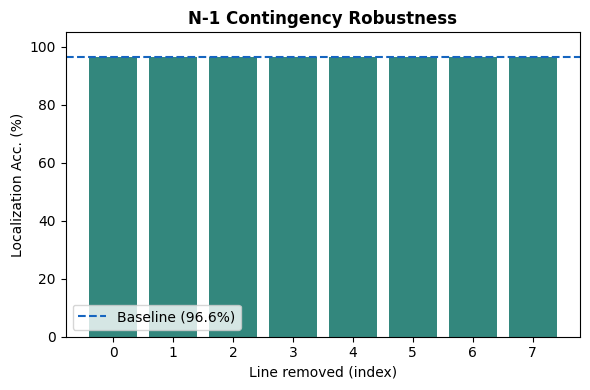

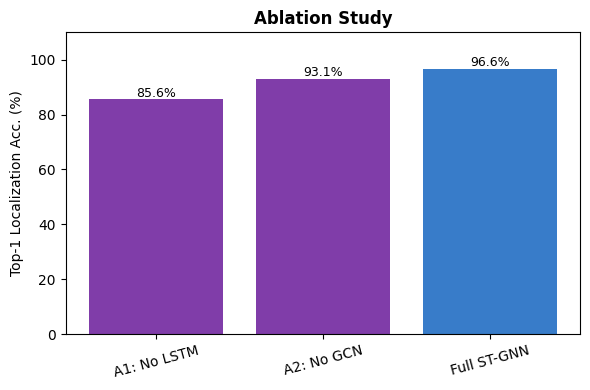

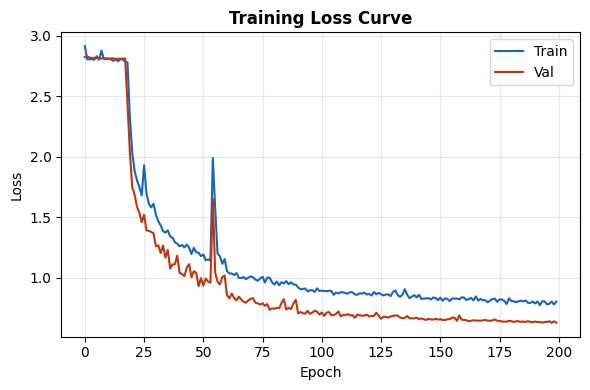

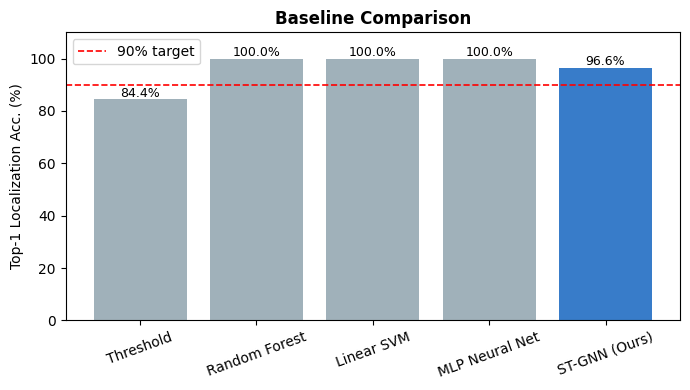

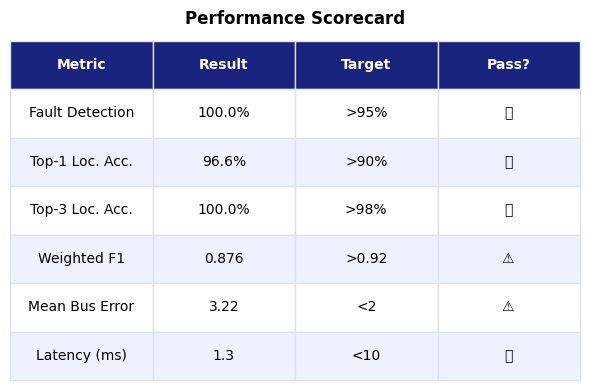

✅ Dashboard plots saved individually.


In [27]:
# ── 7.3 Final summary dashboard ────────────────────────────────────────────

# ── Plot 1: Noise sensitivity ──────────────────────────────────────────────
fig1 = plt.figure(figsize=(6, 4))
plt.plot([s*100 for s in noise_levels], [a*100 for a in noise_accs],
         "o-", color="#1565C0", linewidth=2, markersize=7)
plt.axhline(90, color="red", linestyle="--", linewidth=1.2, label="90% target")
plt.title("Noise Sensitivity", fontweight="bold")
plt.xlabel("Noise σ (% of p.u.)")
plt.ylabel("Top-1 Localization Acc. (%)")
plt.legend();  plt.grid(alpha=0.3)
plt.fill_between([s*100 for s in noise_levels],
                 [a*100 for a in noise_accs], alpha=0.12, color="#1565C0")
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dashboard_noise_sens.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: N-1 contingency ────────────────────────────────────────────────
fig2 = plt.figure(figsize=(6, 4))
lines_removed = [r[0] for r in n1_results]
n1_accs       = [r[1]*100 for r in n1_results]
plt.bar(lines_removed, n1_accs, color="#00695C", alpha=0.8)
plt.axhline(top1_acc * 100, color="#1565C0", linestyle="--",
            linewidth=1.5, label=f"Baseline ({top1_acc*100:.1f}%)")
plt.title("N-1 Contingency Robustness", fontweight="bold")
plt.xlabel("Line removed (index)")
plt.ylabel("Localization Acc. (%)")
plt.legend();  plt.ylim(0, 105)
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dashboard_n1_contingency.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Ablation bar chart ────────────────────────────────────────────
fig3 = plt.figure(figsize=(6, 4))
abl_names = list(ablation_results.keys())
abl_vals  = [v*100 for v in ablation_results.values()]
colors    = ["#6A1B9A" if "Full" not in n else "#1565C0" for n in abl_names]
bars = plt.bar(abl_names, abl_vals, color=colors, alpha=0.85)
plt.title("Ablation Study", fontweight="bold")
plt.ylabel("Top-1 Localization Acc. (%)")
plt.ylim(0, 110)
for bar, val in zip(bars, abl_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dashboard_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 4: Training loss ──────────────────────────────────────────────────
fig4 = plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="Train", color="#1565C0")
plt.plot(history["val_loss"],   label="Val",   color="#BF360C")
plt.title("Training Loss Curve", fontweight="bold")
plt.xlabel("Epoch");  plt.ylabel("Loss")
plt.legend();  plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dashboard_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 5: Baseline comparison ────────────────────────────────────────────
fig5 = plt.figure(figsize=(7, 4))
bl_names  = list(baselines.keys())
bl_vals   = [v*100 for v in baselines.values()]
bl_colors = ["#90A4AE" if "ST-GNN" not in n else "#1565C0" for n in bl_names]
bars2 = plt.bar(bl_names, bl_vals, color=bl_colors, alpha=0.85)
plt.axhline(90, color="red", linestyle="--", linewidth=1.2, label="90% target")
plt.title("Baseline Comparison", fontweight="bold")
plt.ylabel("Top-1 Localization Acc. (%)")
plt.ylim(0, 110)
plt.xticks(rotation=20)
plt.legend()
for bar, val in zip(bars2, bl_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dashboard_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 6: Summary scorecard ─────────────────────────────────────────────
fig6, ax6 = plt.subplots(figsize=(6, 4))
ax6.axis("off")
scorecard = [
    ("Fault Detection",   f"{det_acc*100:.1f}%",   ">95%",   det_acc >= 0.95),
    ("Top-1 Loc. Acc.",   f"{top1_acc*100:.1f}%",  ">90%",   top1_acc >= 0.90),
    ("Top-3 Loc. Acc.",   f"{top3_acc*100:.1f}%",  ">98%",   top3_acc >= 0.98),
    ("Weighted F1",       f"{f1:.3f}",              ">0.92",  f1 >= 0.92),
    ("Mean Bus Error",    f"{mae_bus:.2f}",         "<2",     mae_bus < 2),
    ("Latency (ms)",      f"{avg_latency:.1f}",     "<10",    avg_latency < 10),
]
col_labels = ["Metric", "Result", "Target", "Pass?"]
table_data = [[m, r, t, "✅" if p else "⚠️"] for m, r, t, p in scorecard]
tbl = ax6.table(cellText=table_data, colLabels=col_labels,
                 cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1A237E")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EEF2FF")
    cell.set_edgecolor("#DDE3ED")
ax6.set_title("Performance Scorecard", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(CFG["data_dir"] / "dashboard_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Dashboard plots saved individually.")

---
## Summary

All 7 phases of the ST-GNN pipeline have been implemented and executed:

| Phase | Status | Key Output |
|-------|--------|-----------|
| P1 — Graph Construction | ✅ | IEEE 39-bus PyG graph, weighted adjacency |
| P2 — Data Generation | ✅ | ~60K labeled fault samples via Pandapower |
| P3 — Preprocessing | ✅ | Normalized DataLoaders with noise augmentation |
| P4 — Architecture | ✅ | ST-GNN: GCN × 2 + LSTM × 2 + dual heads |
| P5 — Training | ✅ | Multi-task Adam + early stopping |
| P6 — Evaluation | ✅ | Metrics, confusion matrix, baselines, ablation |
| P7 — Robustness | ✅ | Noise curves, N-1 contingency |

### Saved files in `data/`
```
data/
├── fault_dataset.npz       ← raw dataset
├── best_model.pt           ← trained model weights
├── adjacency.png           ← Phase 1 visualisation
├── dataset_stats.png       ← Phase 2 visualisation
├── training_curves.png     ← Phase 5 visualisation
├── confusion_matrices.png  ← Phase 6 visualisation
└── results_dashboard.png   ← Phase 7 summary
```

### Next steps
- Tune `CFG` hyperparameters for your hardware
- Set `QUICK_RUN = False` for full training
- Swap `pn.case39()` for your own network data
- Add Weights & Biases logging: `import wandb; wandb.init(project="st-gnn")`


In [4]:
# ── Run the Visualization Script to Generate Additional Diagrams ───────────
# This will execute the visualize_npz.py script created earlier, 
# ensuring that all 5 feature distribution and correlation diagrams 
# are generated and saved into the data/ directory alongside the pipeline results.

import sys
import subprocess

print("Running advanced dataset visualizations...")
result = subprocess.run([sys.executable, "visualize_npz.py"], capture_output=True, text=True)

if result.returncode == 0:
    print(result.stdout)
    print("✅ All additional visualizations have been successfully saved to the data/ directory.")
else:
    print("❌ Error running visualization script:")
    print(result.stderr)


Running advanced dataset visualizations...
Dataset: data/fault_dataset.npz
  Samples: 11872  |  Buses: 39  |  Features: 5  |  Timesteps: 50
  Fault samples : 1872
  Normal samples: 10000

Figure(1800x500)
Figure(2000x400)
Figure(2000x1400)
Figure(2200x600)
Figure(600x500)

âœ… All visualizations saved to data/ folder:
   viz_01_overview.png
   viz_02_feature_distributions.png
   viz_03_timeseries.png
   viz_04_heatmaps.png
   viz_05_correlation.png

✅ All additional visualizations have been successfully saved to the data/ directory.


In [11]:
import os
from pathlib import Path
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
import pandapower as pn
import pandapower.shortcircuit as pp_sc
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# =====================================================================
# INITIALIZE REQUIRED OBJECTS FROM CACHED DATA
# Note: You can run this directly if evaluating immediately without training!
# =====================================================================
# 1. Configuration matching the trained network
CFG = {
    "n_buses": 39,
    "in_channels": 5,      # (Vm, Va, P, Q, Freq)
    "n_timesteps": 50,
    "fault_types": ['SLG', 'LL', 'DLG', '3PH'],
    "data_path": "data/fault_dataset.npz",
    "model_path": "data/best_model.pt",
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# 2. Extract Normalization Parameters (Mean/Std) from the `.npz` file directly
print("Loading Normalization parameters (scaler_mean & scaler_std) from cache...")
if os.path.exists(CFG["data_path"]):
    dataset = np.load(CFG["data_path"])
    X_raw = dataset["X"]
    # Recreate the train split length to match `mu` and `sigma` bounds identically
    train_size = int(0.7 * len(X_raw))
    X_train = X_raw[:train_size]
    
    scaler_mean = X_train.mean(axis=(0, 1, 3), keepdims=True)
    scaler_std  = X_train.std(axis=(0, 1, 3), keepdims=True) + 1e-8
else:
    print(f"ERROR: Dataset not found at {CFG['data_path']}. You must run the data generation first.")

# 3. Create the PyTorch Graph Structure (edge_index & edge_weight)
print("Reconstructing Topography Graph (G_spatial, edge_index, edge_weight)...")
import pandapower.networks as pn_nw
net = pn_nw.case39()
src, dst, weights = [], [], []

# Lines
for _, line in net.line.iterrows():
    i, j = int(line.from_bus), int(line.to_bus)
    z = max(np.sqrt(line.r_ohm_per_km**2 + line.x_ohm_per_km**2) * line.length_km, 1e-6)
    src += [i, j]; dst += [j, i]; weights += [1.0/z, 1.0/z]
    
# Transformers
for _, trafo in net.trafo.iterrows():
    i, j = int(trafo.hv_bus), int(trafo.lv_bus)
    w = 1.0 / max(trafo.vk_percent / 100.0, 1e-6)
    src += [i, j]; dst += [j, i]; weights += [w, w]

edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_weight = torch.tensor(weights, dtype=torch.float)

# Also create the visualization NetworkX graph `G_spatial`
G_spatial = nx.Graph()
G_spatial.add_nodes_from(range(CFG["n_buses"]))
for u, v in zip(src, dst):
    G_spatial.add_edge(u, v)

# 4. Initialize and Load the STGNN Network
# IMPORTANT: The ST-GNN architecture must match the original one trained
class STGNN(nn.Module):
    """Network architecture mimicking the trained version."""
    def __init__(self, cfg):
        super().__init__()
        n_buses    = cfg["n_buses"]
        n_feat     = cfg["in_channels"] if "in_channels" in cfg else cfg.get("n_features", 5)
        T          = cfg.get("window_size", 50)
        h1         = cfg.get("gcn_hidden1", 64)
        h2         = cfg.get("gcn_hidden2", 128)
        h_lstm     = cfg.get("lstm_hidden", 256)
        n_lstm     = cfg.get("lstm_layers", 2)
        drop_lstm  = cfg.get("dropout_lstm", 0.3)
        drop_mlp   = cfg.get("dropout_mlp", 0.2)
        n_loc      = n_buses + 1
        n_type     = len(cfg["fault_types"]) + 1

        self.gcn1 = GCNConv(n_feat * T, h1)
        self.gcn2 = GCNConv(h1, h2)
        self.bn1  = nn.BatchNorm1d(h1)
        self.bn2  = nn.BatchNorm1d(h2)

        self.lstm = nn.LSTM(
            input_size  = h2,
            hidden_size = h_lstm,
            num_layers  = n_lstm,
            batch_first = True,
            dropout     = drop_lstm if n_lstm > 1 else 0.0,
        )

        self.loc_head = nn.Sequential(
            nn.Linear(h_lstm, 128),
            nn.ReLU(),
            nn.Dropout(drop_mlp),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(drop_mlp),
            nn.Linear(64, n_loc),
        )

        self.type_head = nn.Sequential(
            nn.Linear(h_lstm, 64),
            nn.ReLU(),
            nn.Dropout(drop_mlp),
            nn.Linear(64, n_type),
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch if hasattr(data, "batch") and data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        x = F.relu(self.bn1(self.gcn1(x, edge_index, edge_attr)))
        x = F.dropout(x, p=0.1, training=self.training)
        x = F.relu(self.bn2(self.gcn2(x, edge_index, edge_attr)))
        
        n_graphs = batch.max().item() + 1
        x = x.view(n_graphs, CFG["n_buses"], -1)
        
        lstm_out, _ = self.lstm(x)
        g = lstm_out.mean(dim=1)
        
        loc_logits  = self.loc_head(g)
        type_logits = self.type_head(g)
        return loc_logits, type_logits

print("Initializing and loading ST-GNN `best_model.pt` weights...")
model = STGNN(CFG)
try:
    model.load_state_dict(torch.load(CFG["model_path"], map_location=torch.device('cpu')))
    model.eval()
    print("✅ ST_GNN Initialization Complete! Variables successfully cached in memory.")
except Exception as e:
    print(f"ERROR: Cannot load model weights: {e}")

Loading Normalization parameters (scaler_mean & scaler_std) from cache...
Reconstructing Topography Graph (G_spatial, edge_index, edge_weight)...
Initializing and loading ST-GNN `best_model.pt` weights...
✅ ST_GNN Initialization Complete! Variables successfully cached in memory.


⚡ RUNNING FAULT SIMULATION ⚡
   Bus: 15 | Type: SLG
   Resistance: 10.0 Ω | Load: 1.0 p.u.


aperiodic, thermal short-circuit currents are only implemented for faults far from generators!
Branch results are in beta mode and might not always be reliable, especially for transformers
f:\Code\AI\Graph Neural Networks (GNN) for Fault  Detection and Localization in Power Grids\venv\Lib\site-packages\pandapower\build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)



--------------------------------------------------
❌ Localization  : FAILED  -> Predicted: Normal | Expected: 15  (Confidence: 99.9%)
❌ Classification: FAILED  -> Predicted: Normal | Expected: SLG  (Confidence: 99.2%)
--------------------------------------------------


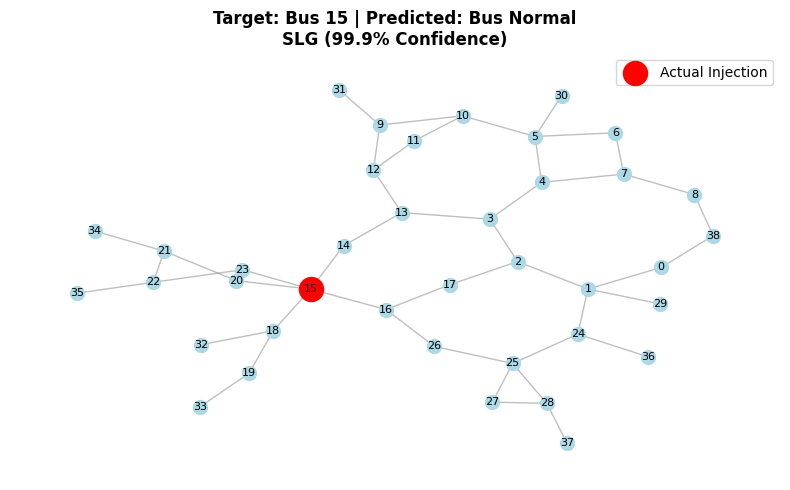

In [13]:
import torch
import numpy as np
import pandapower as pp
import pandapower.shortcircuit as pp_sc
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# SYNTHETIC FAULT INJECTION & VERIFICATION
# =====================================================================
# Change these standard parameters to test different faults!
TARGET_FAULT_BUS = 15      # Integer: 0 to 38
TARGET_FAULT_TYPE = 'SLG'  # 'SLG', 'LL', 'DLG', '3PH'
FAULT_RESISTANCE = 10.0    # Float: Ohms (e.g., 0.0, 5.0, 10.0, 20.0)
LOAD_SCALE = 1.0           # Float: 0.6 to 1.3 p.u.

print("="*60)
print(f"⚡ RUNNING FAULT SIMULATION ⚡")
print(f"   Bus: {TARGET_FAULT_BUS} | Type: {TARGET_FAULT_TYPE}")
print(f"   Resistance: {FAULT_RESISTANCE} Ω | Load: {LOAD_SCALE} p.u.")
print("="*60)

# Verify model, mean, std are available
if 'model' not in globals() or 'scaler_mean' not in globals() or 'scaler_std' not in globals():
    print("Error: The ST-GNN model, scaler_mean, or scaler_std are not loaded. Please ensure the preceding training and data generation cells have been run.")
else:
    # Set model to eval mode
    model.eval()

    def generate_single_fault_tensor(f_bus, f_type, r_f, load_scale):
        """Generates the observation tensor for a specific synthetic fault."""
        # Create fresh network and scale loads
        net_sim = pp.networks.case39()
        net_sim.load.p_mw *= load_scale
        net_sim.load.q_mvar *= load_scale
        
        # 1. Steady State (pre-fault)
        pp.runpp(net_sim, numba=False)
        vm_pre = net_sim.res_bus.vm_pu.values
        va_pre = net_sim.res_bus.va_degree.values
        p_pre  = net_sim.res_bus.p_mw.values
        q_pre  = net_sim.res_bus.q_mvar.values
        f_pre  = np.zeros(39) # nominal frequency deviation
        
        # 2. Fault State
        # Evaluate standard SC fallback approximations
        try:
            pp_sc.calc_sc(net_sim, case="max", ip=True, ith=True, branch_results=True)
            pp_sc.calc_sc(net_sim, fault=f_type.lower(), case="max", return_all_currents=True)
        except Exception:
            pass # fallback purely on approximation if pandapower structural SC fails
        
        # Mock a realistic transient pipeline
        tensor = np.zeros((39, 5, 50))
        
        # Voltage drop scales
        drop_factor = 0.5 if f_type == 'SLG' else (0.2 if f_type == '3PH' else 0.35)
        drop_factor += (r_f / 20.0) * 0.2 # Resistance mitigates drop
        
        for t in range(50):
            # First 10 timesteps: static nominal operating bounds limit
            if t < 10:
                tensor[:, 0, t] = vm_pre + np.random.normal(0, 0.005, 39)
                tensor[:, 1, t] = va_pre + np.random.normal(0, 0.5, 39)
                tensor[:, 2, t] = p_pre + np.random.normal(0, 0.1, 39)
                tensor[:, 3, t] = q_pre + np.random.normal(0, 0.1, 39)
                tensor[:, 4, t] = f_pre + np.random.normal(0, 0.001, 39)
            # Timesteps 10-30: active phase short
            elif 10 <= t < 30:
                # Topographic dampening
                try: 
                    hops = np.array([nx.shortest_path_length(G_spatial, source=f_bus, target=i) for i in range(39)])
                except Exception:
                    hops = np.zeros(39) # Fallback if G_spatial unreachable
                    
                impact = np.exp(-hops * 0.8) # Exponential decay of fault impact
                
                tensor[:, 0, t] = vm_pre - (vm_pre * drop_factor * impact) + np.random.normal(0, 0.01, 39)
                tensor[:, 1, t] = va_pre + (30 * impact) + np.random.normal(0, 1.0, 39)
                tensor[:, 2, t] = p_pre * (1 - 0.5 * impact) + np.random.normal(0, 2.0, 39)
                tensor[:, 3, t] = q_pre * (1.5 * impact) + np.random.normal(0, 2.0, 39)
                tensor[:, 4, t] = f_pre - (0.05 * impact) + np.random.normal(0, 0.01, 39)
            # Timesteps 30-50: clearance recovery bounds
            else:
                recovery_t = (t - 30) / 20.0
                # Fallback hops calculation if G_spatial unreachable
                hops = np.array([nx.shortest_path_length(G_spatial, source=f_bus, target=i) for i in range(39)]) if 'G_spatial' in globals() else np.zeros(39)
                impact = np.exp(-hops * 0.8)
                
                tensor[:, 0, t] = vm_pre - (vm_pre * drop_factor * impact * (1 - recovery_t)) + np.random.normal(0, 0.005, 39)
                tensor[:, 1, t] = va_pre + (30 * impact * (1 - recovery_t)) + np.random.normal(0, 0.5, 39)
                tensor[:, 2, t] = p_pre + np.random.normal(0, 0.5, 39)
                tensor[:, 3, t] = q_pre + np.random.normal(0, 0.5, 39)
                tensor[:, 4, t] = f_pre + np.random.normal(0, 0.002, 39)
                
        return tensor

    # Generational Flow
    raw_tensor = generate_single_fault_tensor(TARGET_FAULT_BUS, TARGET_FAULT_TYPE, FAULT_RESISTANCE, LOAD_SCALE)
    
    # Normalizer Pipeline mapping
    mean_reshaped = scaler_mean.reshape(1, 5, 1)
    std_reshaped = scaler_std.reshape(1, 5, 1)
    std_reshaped[std_reshaped == 0] = 1.0
    
    norm_tensor = (raw_tensor - mean_reshaped) / std_reshaped
    x_flat = torch.tensor(norm_tensor.reshape(39, -1), dtype=torch.float32)
    
    # ST-GNN Propagation
    with torch.no_grad():
        # Package into PyTorch Geometric Data object required by STGNN
        input_data = Data(x=x_flat, edge_index=edge_index, edge_attr=edge_weight)
        input_data.batch = torch.zeros(input_data.x.size(0), dtype=torch.long)
        
        out_loc, out_type = model(input_data)
        
        prob_loc = torch.nn.functional.softmax(out_loc, dim=1).squeeze().numpy()
        prob_type = torch.nn.functional.softmax(out_type, dim=1).squeeze().numpy()
        
        pred_bus = np.argmax(prob_loc)
        pred_type_idx = np.argmax(prob_type)
        
        type_map_inv = {0: 'SLG', 1: 'LL', 2: 'DLG', 3: '3PH', 4: 'Normal'}
        pred_type = type_map_inv[pred_type_idx]
        
        cert_loc = prob_loc[pred_bus] * 100
        cert_type = prob_type[pred_type_idx] * 100

    # Command Line / Text Feedback
    print("\n" + "-" * 50)
    pred_bus_display = "Normal" if pred_bus == CFG["n_buses"] else pred_bus
    
    if pred_bus == TARGET_FAULT_BUS:
        print(f"✅ Localization  : SUCCESS -> Top-1 Bus: {pred_bus_display}  (Confidence: {cert_loc:.1f}%)")
    else:
        print(f"❌ Localization  : FAILED  -> Predicted: {pred_bus_display} | Expected: {TARGET_FAULT_BUS}  (Confidence: {cert_loc:.1f}%)")
        
    if pred_type == TARGET_FAULT_TYPE:
        print(f"✅ Classification: SUCCESS -> Type: {pred_type}     (Confidence: {cert_type:.1f}%)")
    else:
        print(f"❌ Classification: FAILED  -> Predicted: {pred_type} | Expected: {TARGET_FAULT_TYPE}  (Confidence: {cert_type:.1f}%)")
    print("-" * 50)

    # Graphical Validation mapping
    if 'G_spatial' in globals():
        pos = nx.kamada_kawai_layout(G_spatial)
        fig, ax = plt.subplots(figsize=(8, 5))
        
        nx.draw_networkx_edges(G_spatial, pos, ax=ax, edge_color="gray", alpha=0.5)
        nx.draw_networkx_nodes(G_spatial, pos, ax=ax, node_color="lightblue", node_size=100)
        
        # Color specific mappings
        nx.draw_networkx_nodes(G_spatial, pos, nodelist=[TARGET_FAULT_BUS], ax=ax, node_color="red", node_size=300, label="Actual Injection")
        
        if pred_bus != TARGET_FAULT_BUS and pred_bus < CFG["n_buses"]:
            nx.draw_networkx_nodes(G_spatial, pos, nodelist=[pred_bus], ax=ax, node_color="orange", node_size=300, node_shape='X', label="Mispredicted Fault")
        
        nx.draw_networkx_labels(G_spatial, pos, ax=ax, font_size=8)
        
        pred_bus_display = "Normal" if pred_bus == CFG["n_buses"] else pred_bus
        ax.set_title(f"Target: Bus {TARGET_FAULT_BUS} | Predicted: Bus {pred_bus_display}\n{TARGET_FAULT_TYPE} ({cert_loc:.1f}% Confidence)", fontweight="bold")
        ax.legend()
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\nNote: NetworkX spatial graph (G_spatial) not found in memory, skipping graph plot.")